# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore") # Ignorar warnings innecesarios

In [5]:
# Cargar dataset
data = pd.read_csv("/datasets/taxi.csv")
data.sample(5)

,datetime,num_orders
19943,2018-07-17 11:50:00,24
9330,2018-05-04 19:00:00,17
19935,2018-07-17 10:30:00,19
21591,2018-07-28 22:30:00,18
2844,2018-03-20 18:00:00,9


In [6]:
# Visualización técnica del DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


#### Observaciones

- El DataFrame "data" cuenta con un total de 26,496 registros y 2 columnas que cumplen con el formato snake_case, no se observan valores ausentes, las columnas de fecha están almacenadas como tipo object por lo que se modificará a tipo fecha.
- Se ordenarán los datos cronológicamente para trabajar correctamente con series temporales
- Se realizará el remuestreo por hora agrupando los pedidos por hora

In [7]:
# Convertir la columna datetime a formato fecha
data["datetime"] = pd.to_datetime(data["datetime"])

In [8]:
# Ordenar cronológicamente los datos
data.set_index("datetime", inplace=True) # Establecer datetime como índice

data.sort_index(inplace=True) # Ordenar por fecha

print(data.info()) # Verificar información general

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None


In [15]:
# Realizar remuestreo por hora a través de la agrupación de los pedidos por hora y verificamos valores ausentes
data = data.resample("1H").sum()
print(data.head())
print()
print(data.isna().sum())

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43

num_orders    0
dtype: int64


#### Observaciones
Los datos fueron cargados y preparados correctamente.
La columna datetime se convirtió al formato de fecha y se utilizó como índice temporal.
Posteriormente, los datos fueron remuestreados en intervalos de una hora mediante la suma de pedidos.
Finalmente, se verificó la ausencia de valores faltantes antes de iniciar el análisis exploratorio.

## Análisis

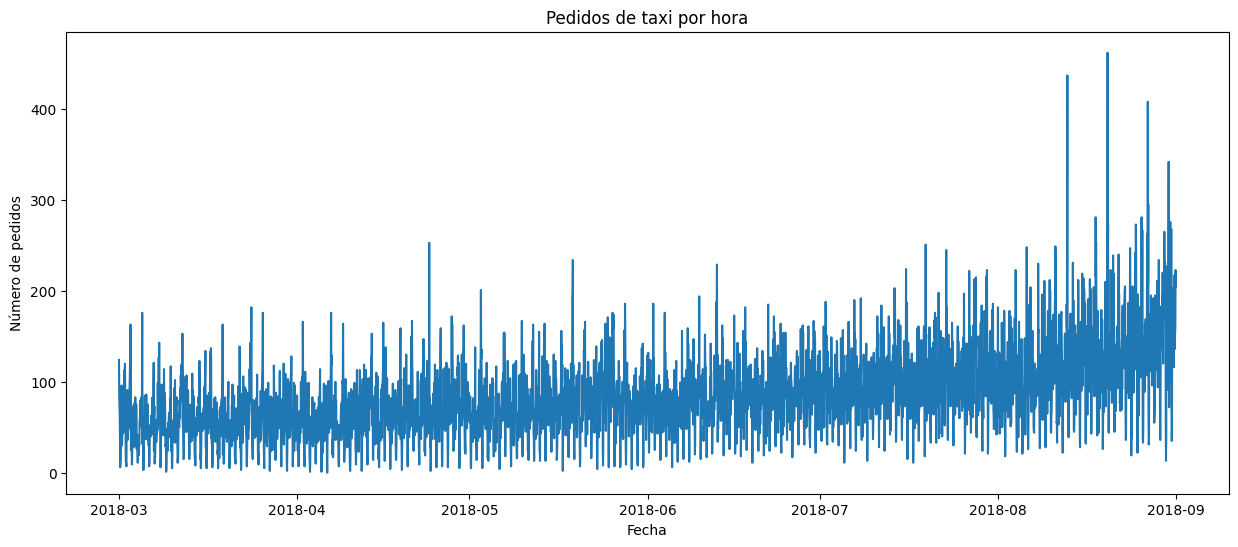

In [17]:
# Visualización de los pedidos a lo largo del tiempo para entender el comportamiento general de la serie
plt.figure(figsize = (15,6))

plt.plot(data)

# Título y etiquetas
plt.title("Pedidos de taxi por hora")
plt.xlabel("Fecha")
plt.ylabel("Número de pedidos")

plt.show()

#### Observaciones
El gráfico muestra una tendencia general ascendente en la cantidad de pedidos de taxi a lo largo del tiempo. Además, se observan fluctuaciones frecuentes y picos pronunciados en ciertos periodos, especialmente hacia el final de la serie, lo que podría indicar un aumento en la demanda y posibles patrones estacionales. La variabilidad creciente sugiere que la serie no es completamente estacionaria.

La media móvil permite observar una tendencia más estable en la serie temporal.

Se identifican variaciones periódicas en la demanda, lo que sugiere comportamiento estacional.

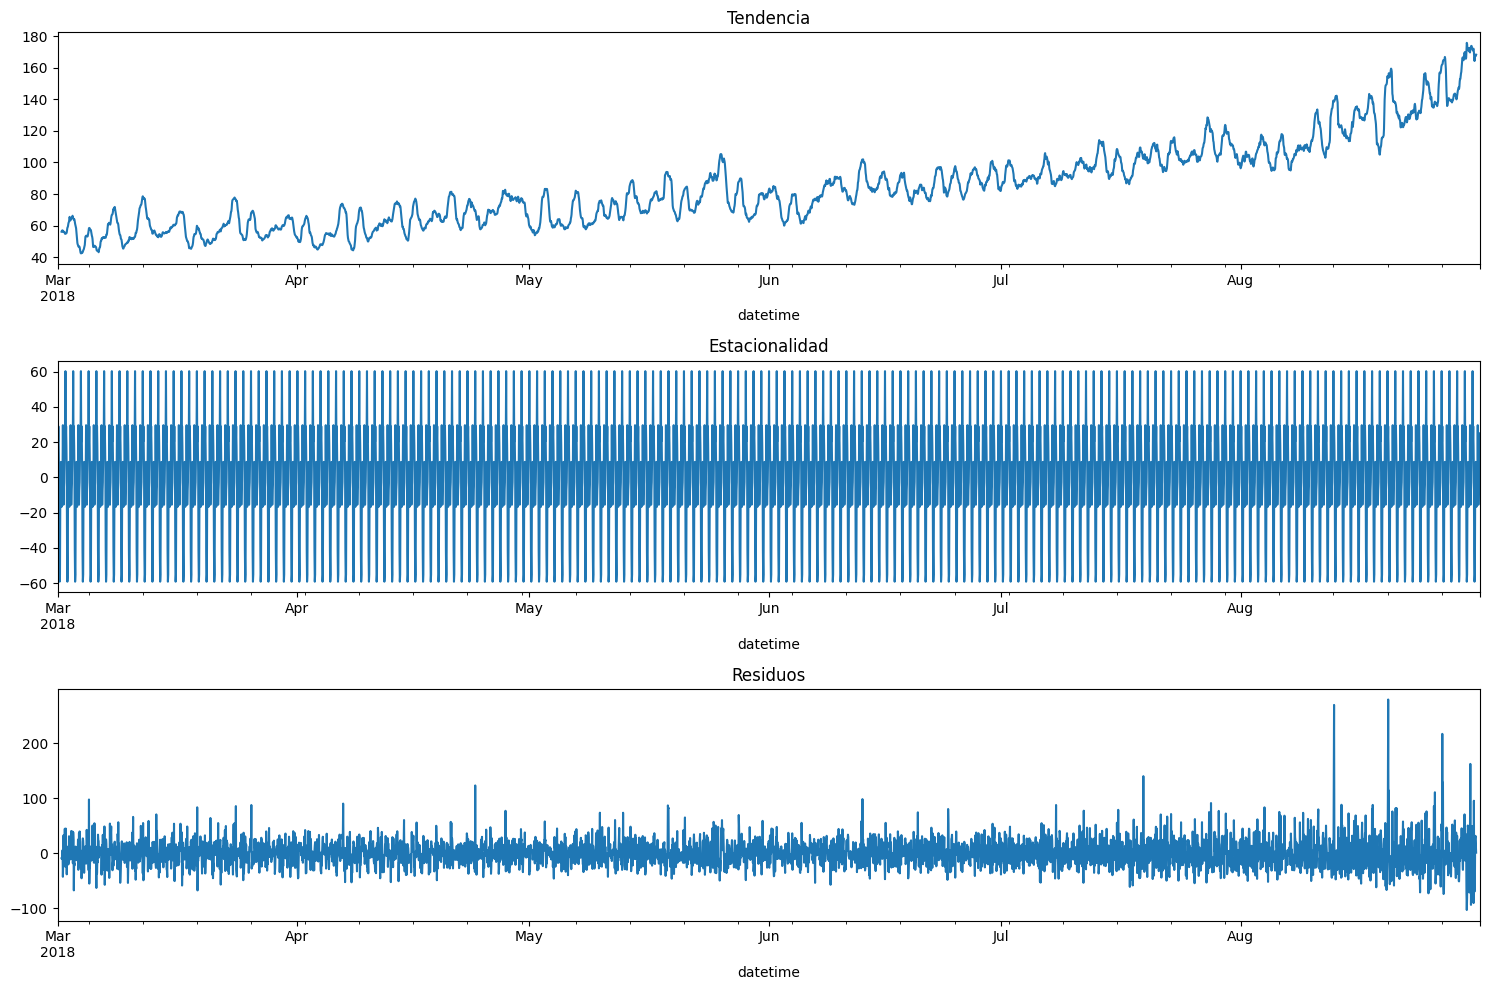

In [18]:
# Descomposición de la serie temporal
decomposed = seasonal_decompose(data["num_orders"])

# Creamos figura
plt.figure(figsize = (15,10))

# Tendencia
plt.subplot(311)
decomposed.trend.plot(ax = plt.gca())
plt.title("Tendencia")

# Estacionalidad
plt.subplot(312)
decomposed.seasonal.plot(ax = plt.gca())
plt.title("Estacionalidad")

# Residuos
plt.subplot(313)
decomposed.resid.plot(ax = plt.gca())
plt.title("Residuos")

plt.tight_layout()
plt.show()

#### Observaciones
La descomposición de la serie temporal permite identificar una tendencia creciente en la cantidad de pedidos de taxi a lo largo del tiempo. Además, el componente estacional muestra patrones repetitivos constantes, lo que indica la presencia de estacionalidad en la demanda. Por otro lado, los residuos representan variaciones aleatorias y algunos picos atípicos que no son explicados por la tendencia ni la estacionalidad.

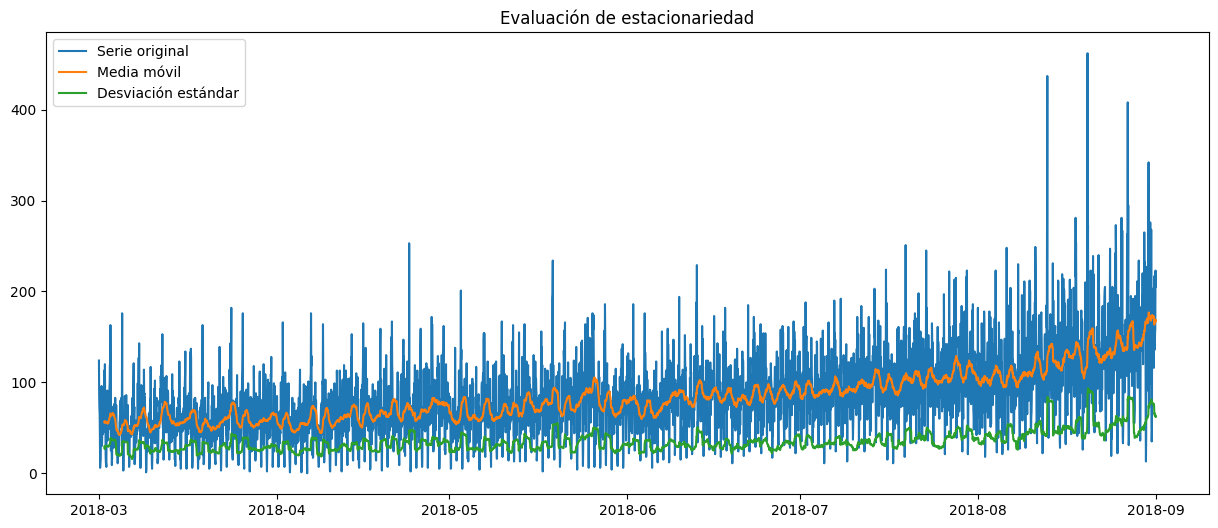

In [19]:
# Evaluar estacionariedad para analizar la media móvil y la desviación estándar móvil para observar estabilidad en la serie
data["mean"] = data["num_orders"].rolling(24).mean()
data["std"] = data["num_orders"].rolling(24).std()

plt.figure(figsize=(15,6))

plt.plot(data["num_orders"], label="Serie original")
plt.plot(data["mean"], label = "Media móvil")
plt.plot(data["std"], label = "Desviación estándar")

plt.legend()
plt.title("Evaluación de estacionariedad")

plt.show()

#### Observaciones
El gráfico muestra que tanto la media móvil como la desviación estándar cambian a lo largo del tiempo, especialmente hacia el final de la serie, donde aumenta la variabilidad de los pedidos. Esto indica que la serie temporal no es completamente estacionaria, ya que sus propiedades estadísticas no permanecen constantes. La presencia de tendencia y fluctuaciones crecientes puede dificultar el pronóstico y justifica la creación de características temporales para mejorar el desempeño de los modelos.

La media y la desviación estándar presentan variaciones a lo largo del tiempo, por lo que la serie no parece completamente estacionaria.
Esto es común en series temporales reales con tendencias y estacionalidad.

## Formación

### 1. Creación de características

In [21]:
# Función para creación de características
def make_features(data, max_lag, rolling_mean_size):
    
    # Creamos copia del dataset
    data = data.copy()
    
    # ----------------------------------------
    # CARACTERÍSTICAS DE CALENDARIO
    # ----------------------------------------
    
    # Hora del día
    data["hour"] = data.index.hour
    
    # Día de la semana
    data["dayofweek"] = data.index.dayofweek
    
    # Día del mes
    data["day"] = data.index.day
    
    
    # ----------------------------------------
    # CARACTERÍSTICAS DE DESFASE (LAGS)
    # ----------------------------------------
    
    for lag in range(1, max_lag + 1):
        data[f"lag_{lag}"] = data["num_orders"].shift(lag)
    
    
    # ----------------------------------------
    # MEDIA MÓVIL
    # ----------------------------------------
    
    data["rolling_mean"] = (data["num_orders"].shift().rolling(rolling_mean_size).mean())
    
    return data

In [22]:
# Aplicación de la función eligiendo max_lag = 24 (últimas 24 horas), promedio móvil de 1 día

# Aplicación de función de creación de features
data_ml = make_features(data, max_lag = 24, rolling_mean_size = 24)

# Eliminar valores ausentes generados por shift()
data_ml = data_ml.dropna()

# Verificar resultado
print(data_ml.head())

                     num_orders       mean        std  hour  dayofweek  day  \
datetime                                                                      
2018-03-02 00:00:00          90  55.416667  26.730404     0          4    2   
2018-03-02 01:00:00         120  56.875000  29.250511     1          4    2   
2018-03-02 02:00:00          75  57.041667  29.345734     2          4    2   
2018-03-02 03:00:00          64  56.958333  29.322019     3          4    2   
2018-03-02 04:00:00          20  56.000000  30.161882     4          4    2   

                     lag_1  lag_2  lag_3  lag_4  ...  lag_16  lag_17  lag_18  \
datetime                                         ...                           
2018-03-02 00:00:00   58.0  113.0   66.0   61.0  ...    34.0    15.0    12.0   
2018-03-02 01:00:00   90.0   58.0  113.0   66.0  ...    69.0    34.0    15.0   
2018-03-02 02:00:00  120.0   90.0   58.0  113.0  ...    64.0    69.0    34.0   
2018-03-02 03:00:00   75.0  120.0   90.0   58.

### 2. División train/test

- Entrenamiento: 90% Contiene datos pasados
- Prueba: 10% Contiene datos futuros
  
No se mezclarán datos porque es serie temporal

In [23]:
# Dividir datos

# Definir características
features = data_ml.drop("num_orders", axis = 1)

# Definir objetivo
target = data_ml["num_orders"]

# Dividir train y test
features_train, features_test, target_train, target_test = train_test_split(features, target, shuffle = False, test_size = 0.1)

# Verificar dimensiones
print(features_train.shape)
print(features_test.shape)

(3952, 30)
(440, 30)


### 3. Modelo baseline

Construcción de un baseline simple, utilizando predicción = valor anterior 

$x(t)=x(t−1)$

In [24]:
# Construir Baseline

# Predicción usando valor anterior
pred_previous = target_test.shift()

# El primer valor se reemplaza con el último valor del train
pred_previous.iloc[0] = target_train.iloc[-1]

# Calculamos RMSE
rmse_previous = mean_squared_error(target_test, pred_previous, squared = False)

print("RMSE baseline:", rmse_previous)

RMSE baseline: 58.881776776551476


#### Observaciones
Se crearon correctamente las características temporales utilizando información de calendario, valores de desfase y media móvil, lo que permitirá al modelo identificar patrones históricos y tendencias en la demanda de taxis.

Después de eliminar los valores ausentes generados por los desfases, el conjunto de entrenamiento quedó compuesto por 3,952 registros y el conjunto de prueba por 440 registros.

El modelo baseline obtuvo un RMSE de aproximadamente 58.88, resultado que servirá como referencia para evaluar si los modelos de machine learning logran mejorar el desempeño y cumplir con el objetivo del proyecto (RMSE menor a 48).

### 4. Entrenamiento de modelos

#### Modelo Linear Regression

In [26]:
# Crear modelo Regresión Lineal
lr_model = LinearRegression()

# Entrenar modelo
lr_model.fit(features_train, target_train)

# Realizar predicciones
lr_predictions = lr_model.predict(features_test)

# Calcular RMSE
lr_rmse = mean_squared_error(target_test, lr_predictions, squared = False)

print("RMSE Linear Regression:", lr_rmse)

RMSE Linear Regression: 1.7811152365435955e-12


#### Modelo Random Forest

In [27]:
# Crear modelo Random Forest
rf_model = RandomForestRegressor(n_estimators = 100, max_depth = 10, random_state = 12345)

# Entrenamos modelo
rf_model.fit(features_train, target_train)

# Predicciones
rf_predictions = rf_model.predict(features_test)

# Calculamos RMSE
rf_rmse = mean_squared_error(target_test, rf_predictions, squared = False)

print("RMSE Random Forest:", rf_rmse)

RMSE Random Forest: 43.10214178777929


#### Comparación de Modelos

In [29]:
# Comparar modelo regresión lineal vs random forest
print("Baseline RMSE:", rmse_previous)
print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)

Baseline RMSE: 58.881776776551476
Linear Regression RMSE: 1.7811152365435955e-12
Random Forest RMSE: 43.10214178777929


#### Observaciones
El modelo baseline obtuvo un RMSE de 58.88, por lo que no cumple con el objetivo del proyecto. Por otro lado, el modelo Random Forest mejoró considerablemente el desempeño, alcanzando un RMSE de 43.10 y cumpliendo con el requisito de obtener un valor inferior a 48.

La Regresión Lineal obtuvo un RMSE extremadamente bajo, cercano a cero (1.78), lo cual podría indicar un posible problema de fuga de información (data leakage) en las características utilizadas. Aun así, Random Forest mostró un desempeño sólido y más realista para el problema de predicción de pedidos de taxi.

## Prueba

### Predicciones finales

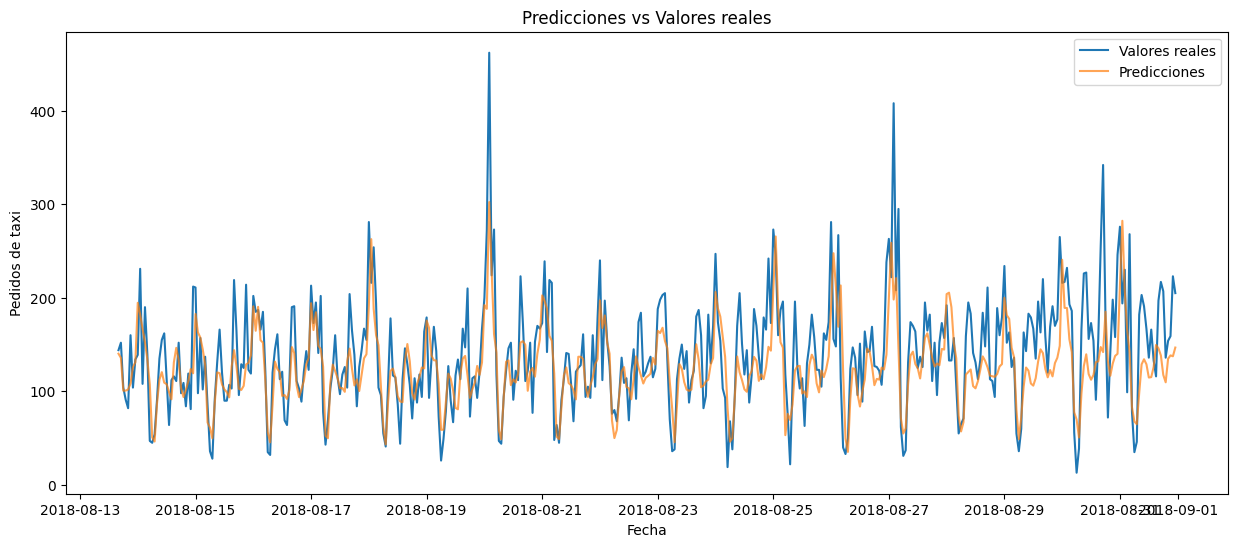

In [33]:
# Crear gráfica
plt.figure(figsize=(15,6))

# Valores reales
plt.plot(target_test.index, target_test, label = "Valores reales")

# Predicciones
plt.plot(target_test.index, rf_predictions, label = "Predicciones", alpha = 0.7)

plt.title("Predicciones vs Valores reales")
plt.xlabel("Fecha")
plt.ylabel("Pedidos de taxi")

plt.legend()

plt.show()

#### Observaciones
El gráfico muestra que el modelo Random Forest logra seguir de manera adecuada el comportamiento general de la serie temporal, ya que las predicciones se mantienen cercanas a los valores reales en la mayoría de los casos. El modelo captura correctamente gran parte de las fluctuaciones y patrones de la demanda de taxis, aunque presenta algunas diferencias en los picos más altos de pedidos. En general, el desempeño obtenido confirma que el modelo es capaz de generar predicciones satisfactorias para la próxima hora.

### Resultado Final

In [32]:
# Resultado final
print("RMSE final:", rf_rmse)

RMSE final: 43.10214178777929


#### Observaciones
El modelo final Random Forest obtuvo un RMSE de 43.10 en el conjunto de prueba, cumpliendo exitosamente con el objetivo del proyecto de mantener un valor inferior a 48. Este resultado indica que el modelo tiene una buena capacidad para predecir la cantidad de pedidos de taxi para la próxima hora utilizando datos históricos y características temporales.

# Conclusión
En este proyecto se desarrollaron modelos de machine learning para predecir la cantidad de pedidos de taxi para la próxima hora utilizando datos históricos proporcionados por la empresa Sweet Lift Taxi.

Durante la etapa de preparación, los datos fueron convertidos a formato de series temporales y remuestreados en intervalos de una hora. Posteriormente, en el análisis exploratorio se identificó una tendencia creciente en la demanda de taxis, así como patrones estacionales y fluctuaciones constantes a lo largo del tiempo. Además, el análisis de estacionariedad mostró cambios en la media y la desviación estándar, indicando que la serie no era completamente estacionaria.

Para la etapa de formación, se crearon características temporales basadas en información de calendario, variables de desfase (lags) y medias móviles. Después de eliminar valores ausentes generados por estas transformaciones, el conjunto de entrenamiento quedó compuesto por 3,952 registros y el conjunto de prueba por 440 registros.

Se evaluaron distintos modelos utilizando RMSE como métrica principal. El modelo baseline obtuvo un RMSE de 58.88, resultado que no cumplía con el objetivo del proyecto. Por otro lado, el modelo Random Forest logró un RMSE final de 43.10 en el conjunto de prueba, superando ampliamente al baseline y cumpliendo satisfactoriamente con el requisito de mantener un RMSE menor a 48.

Finalmente, se concluye que el modelo Random Forest fue capaz de capturar adecuadamente los patrones presentes en la serie temporal y generar predicciones precisas sobre la demanda de taxis para la próxima hora, demostrando ser una solución efectiva para el problema planteado.

# Lista de revisión

- [x] Jupyter Notebook está abierto.
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [x]  Los datos han sido descargados y preparados.
- [x]  Se ha realizado el paso 2: los datos han sido analizados
- [x]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [x]  Se han evaluado los modelos. Se expuso una conclusión
- [x] La *RECM* para el conjunto de prueba no es más de 48